# 04 - Results: Classic tree models

#### Setup configuration

In [34]:
import time

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plt

from src.data.load_raw import load_raw_data
from src.data.preprocess import (
    extract_xy,
    merge_features_and_labels,
    standardize_splits,
)
from src.data.split import split_labeled_transactions
from src.evaluation.metrics import calculate_binary_metrics
from src.evaluation.threshold import find_best_f1_threshold
from src.models.classic import (
    build_dummy_classifier,
    build_logistic_regression,
    build_random_forest,
    build_xgboost,
)

features_df, classes_df, edges_df = load_raw_data()

transactions_df = merge_features_and_labels(
    features_df,
    classes_df,
)

splits = split_labeled_transactions(transactions_df)

#### Setup 'local' data split

In [ ]:
x_train, y_train = extract_xy(
    splits.train,
    feature_set="local",
)

x_validation, y_validation = extract_xy(
    splits.validation,
    feature_set="local",
)

x_test, y_test = extract_xy(
    splits.test,
    feature_set="local",
)

(
    scaler,
    x_train_scaled,
    x_validation_scaled,
    x_test_scaled,
) = standardize_splits(
    x_train,
    x_validation,
    x_test,
)

#### Setup 'all' data split

In [ ]:
x_all_train, y_all_train = extract_xy(
    splits.train,
    feature_set="all",
)

x_all_validation, y_all_validation = extract_xy(
    splits.validation,
    feature_set="all",
)

x_all_test, y_all_test = extract_xy(
    splits.test,
    feature_set="all",
)

(
    all_scaler,
    x_all_train_scaled,
    x_all_validation_scaled,
    x_all_test_scaled,
) = standardize_splits(
    x_all_train,
    x_all_validation,
    x_all_test,
)

In [ ]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = negative_count / positive_count

In [ ]:
results = []

def run_experiment(model_name, model, x_train, y_train, x_validation, y_validation, x_test, y_test):
    start_time = time.perf_counter()

    model.fit(x_train, y_train)

    training_time = time.perf_counter() - start_time

    validation_scores = model.predict_proba(x_validation)[:, 1]

    threshold = find_best_f1_threshold(y_validation, validation_scores)

    test_scores = model.predict_proba(x_test)[:, 1]

    metrics = calculate_binary_metrics(y_test, test_scores, threshold=threshold)

    metrics.update(
        {
            "model": model_name,
            "feature_set": "local",
            "training_time_seconds": training_time,
        }
    )

    results.append(metrics)

    return model, metrics

### Training on 'local' features with time series 70-15-15 split

#### Dummy model

In [ ]:
dummy_model, dummy_metrics = run_experiment(
    model_name="Dummy Classifier (local)",
    model=build_dummy_classifier(),
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    x_test=x_test,
    y_test=y_test
)

#### Logistic regression

In [6]:
logistic_model, logistic_metrics = run_experiment(
    model_name="Logistic Regression (local)",
    model=build_logistic_regression(
        solver='lbfgs',
        penalty='l2',
        C=9642.769020742975,
        class_weight=None,
        max_iter=1500
    ),
    x_train=x_train_scaled,
    y_train=y_train,
    x_validation=x_validation_scaled,
    y_validation=y_validation,
    x_test=x_test_scaled,
    y_test=y_test
)


C:\Users\pansm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


#### Random Forest

In [7]:
random_forest_model, random_forest_metrics = run_experiment(
    model_name="Random Forest (local)",
    model=build_random_forest(
        n_estimators=500,
        max_depth=None,
        min_samples_split=20,
        min_samples_leaf=11,
        max_features='log2',
        class_weight='balanced_subsample'
    ),
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    x_test=x_test,
    y_test=y_test
)

#### XGBoost

In [8]:
xgboost_model, xgboost_metrics = run_experiment(
    model_name="XGBoost (local)",
    model=build_xgboost(
        learning_rate=0.13619423624369625,
        n_estimators=300,
        max_depth=7,
        min_child_weight=2,
        gamma=1.6113481494143387,
        subsample=0.5656066870561047,
        colsample_bytree=0.5760635388828816,
        reg_alpha=9.764048688630152e-06,
        reg_lambda=1.2107315313358617e-06,
        scale_pos_weight=scale_pos_weight
    ),
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    x_test=x_test,
    y_test=y_test
)

scale_pos_weight: 7.634893125361063


### Training on 'all' features with time series 70-15-15 split

#### Logistic Regression

In [ ]:
lr_all_model, lr_all_metrics = run_experiment(
    model_name="Logistic Regression (all)",
    model=build_logistic_regression(
        solver='lbfgs',
        penalty='l2',
        C=9642.769020742975,
        class_weight=None,
        max_iter=1500
    ),
    x_train=x_train_scaled,
    y_train=y_train,
    x_validation=x_validation_scaled,
    y_validation=y_validation,
    x_test=x_test_scaled,
    y_test=y_test
)

#### Random Forest

In [ ]:
rf_all_model, rf_all_metrics = run_experiment(
    model_name="Random Forest (all)",
    model=build_random_forest(
        n_estimators=500,
        max_depth=None,
        min_samples_split=20,
        min_samples_leaf=11,
        max_features='log2',
        class_weight='balanced_subsample'
    ),
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    x_test=x_test,
    y_test=y_test
)

#### XGBoost

In [ ]:
xgb_all_model, xgb_all_metrics = run_experiment(
    model_name="XGBoost  (all)",
    model=build_xgboost(
        learning_rate=0.13619423624369625,
        n_estimators=300,
        max_depth=7,
        min_child_weight=2,
        gamma=1.6113481494143387,
        subsample=0.5656066870561047,
        colsample_bytree=0.5760635388828816,
        reg_alpha=9.764048688630152e-06,
        reg_lambda=1.2107315313358617e-06,
        scale_pos_weight=scale_pos_weight
    ),
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    x_test=x_test,
    y_test=y_test
)

## Results (Time series 70-15-15 split)

In [11]:
results_df = pd.DataFrame(results)

columns = [
    "model",
    "feature_set",
    "pr_auc",
    "roc_auc",
    "precision_illicit",
    "recall_illicit",
    "f1_illicit",
    "threshold",
    "training_time_seconds",
]

results_df[columns].sort_values(
    by="pr_auc",
    ascending=False,
).style.format(
    {
        "pr_auc": "{:.4f}",
        "roc_auc": "{:.4f}",
        "precision_illicit": "{:.4f}",
        "recall_illicit": "{:.4f}",
        "f1_illicit": "{:.4f}",
        "threshold": "{:.2f}",
        "training_time_seconds": "{:.2f}",
    }
)

display(results_df)

,pr_auc,roc_auc,precision_illicit,recall_illicit,f1_illicit,confusion_matrix,threshold,model,feature_set,training_time_seconds
0,0.046149,0.500000,0.046149,1.000000,0.088226,"[[0, 8433], [0, 408]]",0.01,Dummy Classifier,local,0.001234
1,0.367323,0.826025,0.692884,0.453431,0.548148,"[[8351, 82], [223, 185]]",0.74,Logistic Regression,local,0.491117
2,0.528419,0.820667,0.846154,0.431373,0.571429,"[[8401, 32], [232, 176]]",0.82,Random Forest,local,1.847765
3,0.535152,0.823826,0.705224,0.463235,0.559172,"[[8354, 79], [219, 189]]",0.67,XGBoost,local,0.494869
4,0.262432,0.847223,0.363806,0.477941,0.413136,"[[8092, 341], [213, 195]]",0.54,Logistic Regression,all,1.561895
5,0.541493,0.853726,0.871560,0.465686,0.607029,"[[8405, 28], [218, 190]]",0.68,Random Forest,all,2.044990
6,0.555923,0.841038,0.866071,0.475490,0.613924,"[[8403, 30], [214, 194]]",0.78,XGBoost,all,0.596105


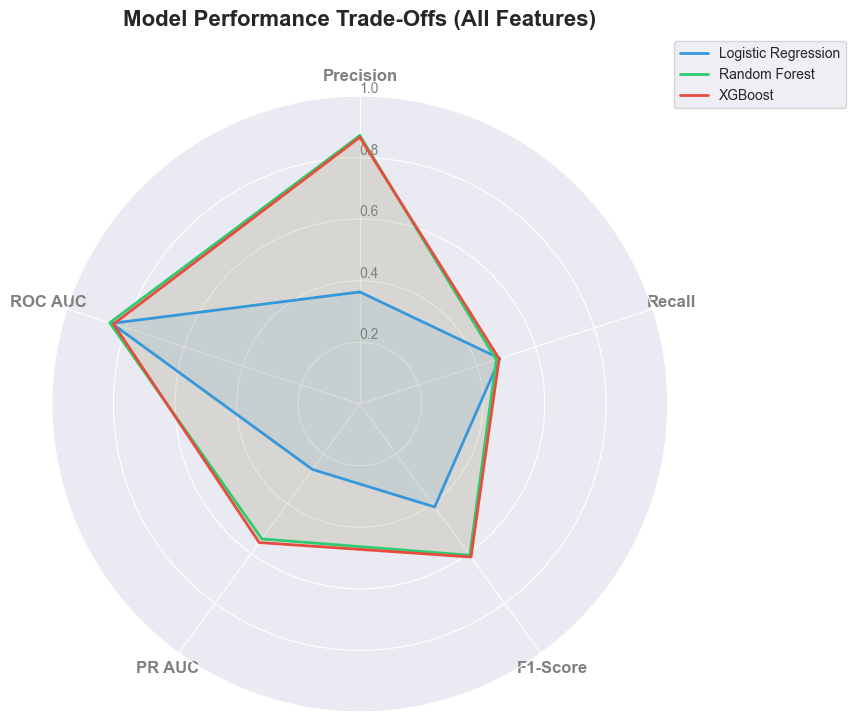

In [35]:
categories = ['Precision', 'Recall', 'F1-Score', 'PR AUC', 'ROC AUC']
N = len(categories)

df_filtered = results_df[results_df['feature_set'] == 'all']

metric_cols = ['precision_illicit', 'recall_illicit', 'f1_illicit', 'pr_auc', 'roc_auc']

models_data = {}
for index, row in df_filtered.iterrows():
    models_data[row['model']] = row[metric_cols].tolist()

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories, color='grey', size=12, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.0)

colors = ['#3498db', '#2ecc71', '#e74c3c']

for (model_name, data), color in zip(models_data.items(), colors):
    values = data + data[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_name, color=color)
    ax.fill(angles, values, color=color, alpha=0.1)

plt.title('Model Performance Trade-Offs (All Features)', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

## XAI for test dataset

#### Poor performance on test dataset due to concept drift

In [32]:
def plot_f1_over_time(model, model_name, x_test, y_test, threshold):
    probs = model.predict_proba(x_test)[:, 1]

    preds = (probs >= threshold).astype(int)

    temp_df = pd.DataFrame({
        'time_step': x_test['time_step'].values,
        'y_true': y_test.values if hasattr(y_test, 'values') else y_test,
        'y_pred': preds
    })

    timesteps = sorted(temp_df['time_step'].unique())
    f1_scores = []

    for ts in timesteps:
        ts_data = temp_df[temp_df['time_step'] == ts]

        if ts_data['y_true'].sum() == 0:
            f1_scores.append(np.nan)
        else:
            f1 = f1_score(ts_data['y_true'], ts_data['y_pred'], zero_division=0)
            f1_scores.append(f1)

    plt.figure(figsize=(14, 6))

    sns.lineplot(x=timesteps, y=f1_scores, marker='o', linewidth=2, color='#e74c3c')

    plt.axvline(x=43, color='black', linestyle='--', alpha=0.7, label='AlphaBay takedown')

    plt.title(f'{model_name} F1 Score Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('F1 Score (Illicit)', fontsize=12)
    plt.ylim(-0.05, 1.05)

    plt.xticks(timesteps, rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

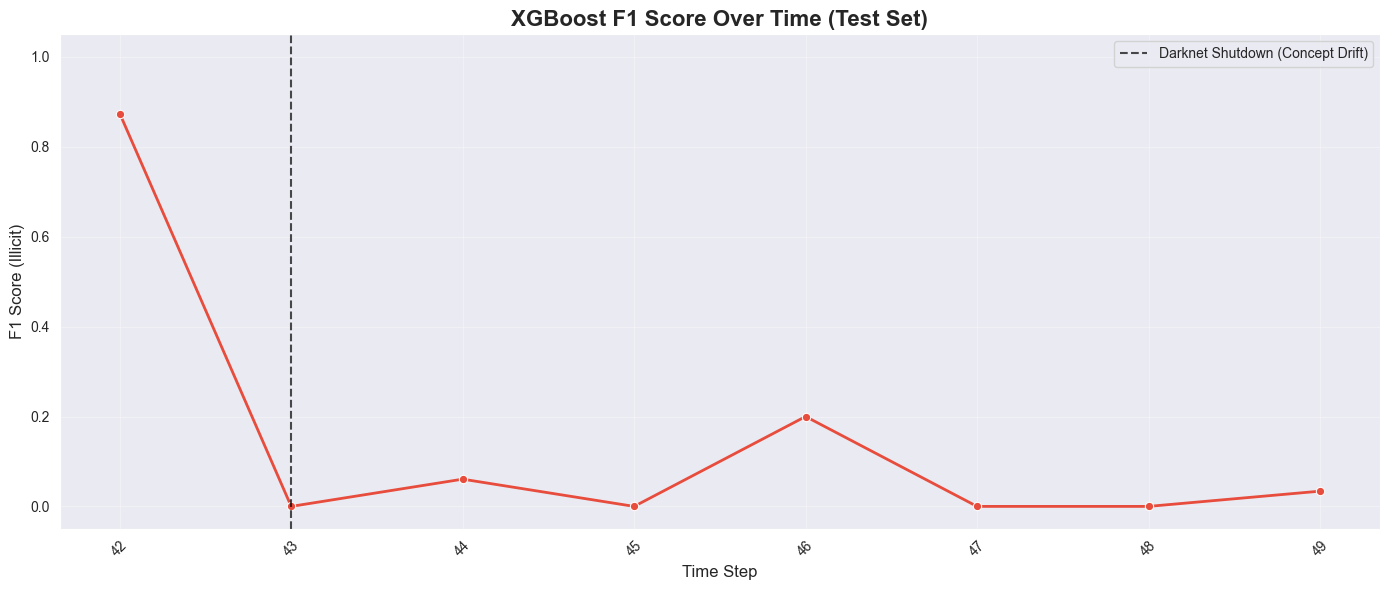

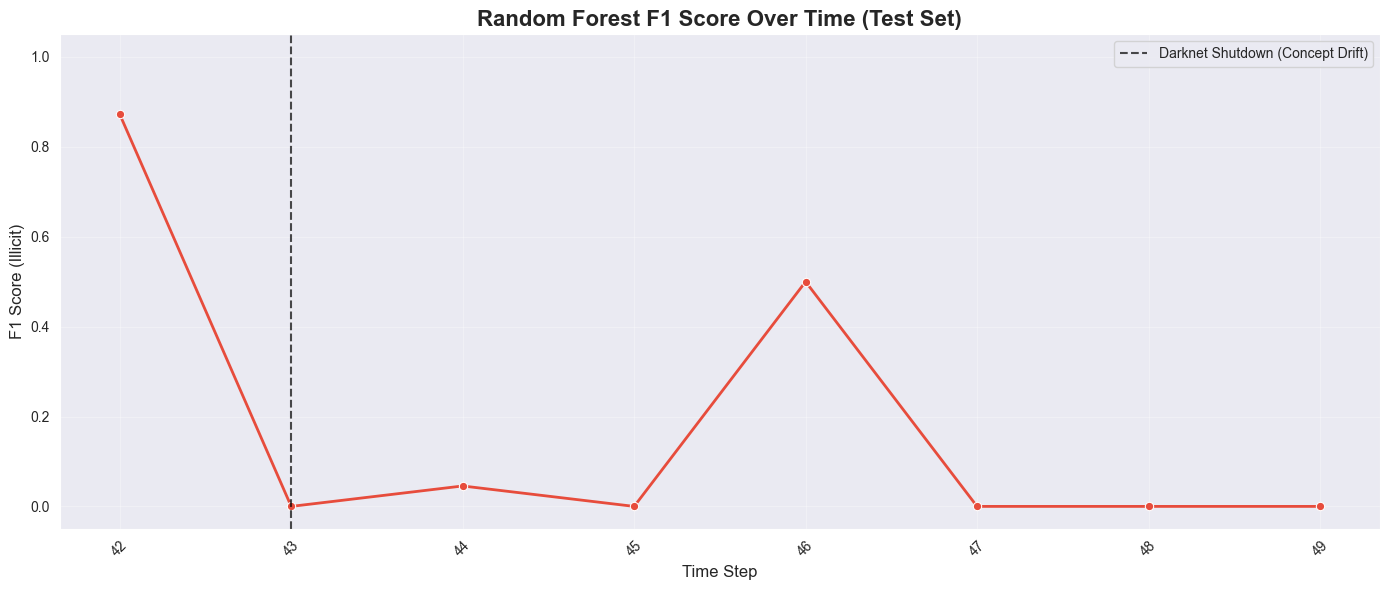

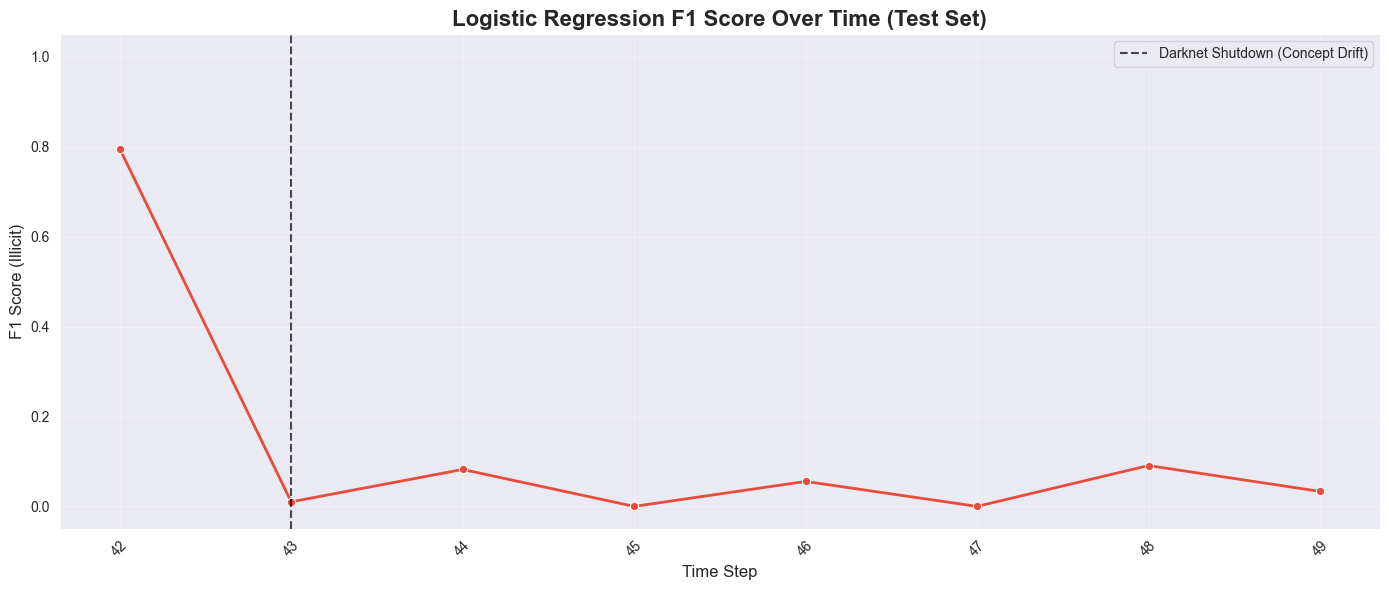

In [33]:
plot_f1_over_time(xgb_all_model, 'XGBoost', x_all_test, y_all_test, threshold=0.78)
plot_f1_over_time(rf_all_model, 'Random Forest', x_all_test, y_all_test, threshold=0.68)
plot_f1_over_time(lr_all_model, 'Logistic Regression', x_all_test, y_all_test, threshold=0.54)

#### Feature analysis

C:\Users\pansm\AppData\Local\Temp\ipykernel_18084\170920386.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette=colors)


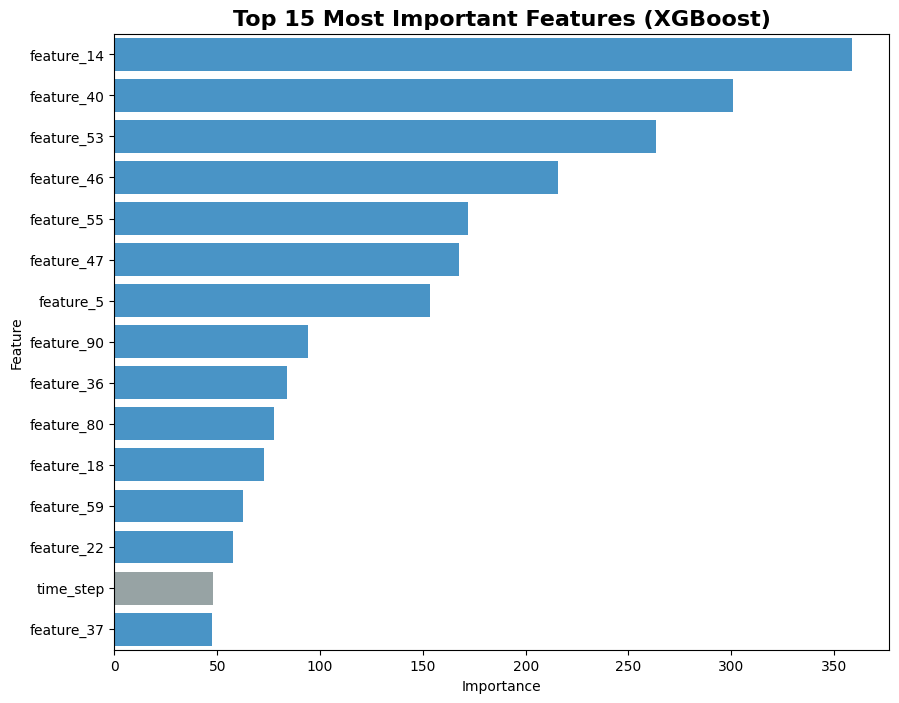

In [23]:
def plot_top_features(model, x_train, top_n=15):
    # 1. Get feature names and importances directly from the booster
    # This is safer than relying on DataFrame column alignment
    booster = model.get_booster()
    feature_names = booster.feature_names
    importances = booster.get_score(importance_type='gain') # 'gain' is usually better than 'weight'

    # 2. Map importances to the correct feature names
    # Note: get_score returns a dict, so we align it with our list of names
    importance_list = [importances.get(f, 0) for f in feature_names]

    # 3. Create DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance_list
    })

    # 4. Filter and Sort
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(top_n)

    # 5. Color mapping (same as before)
    colors = []
    for feat in importance_df['Feature']:
        if 'time_step' in feat:
             colors.append('#95a5a6')
        else:
            # Handle feature naming (assuming 'feature_1' format)
            try:
                feat_num = int(feat.split('_')[1])
                colors.append('#3498db' if feat_num <= 93 else '#e67e22')
            except:
                colors.append('#3498db')

    # 6. Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette=colors)
    plt.title(f'Top {top_n} Most Important Features (XGBoost)', fontsize=16, fontweight='bold')
    plt.show()

# Run it
plot_top_features(xgboost_model, x_all_train)

C:\Users\pansm\AppData\Local\Temp\ipykernel_18084\2854952760.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette=colors)


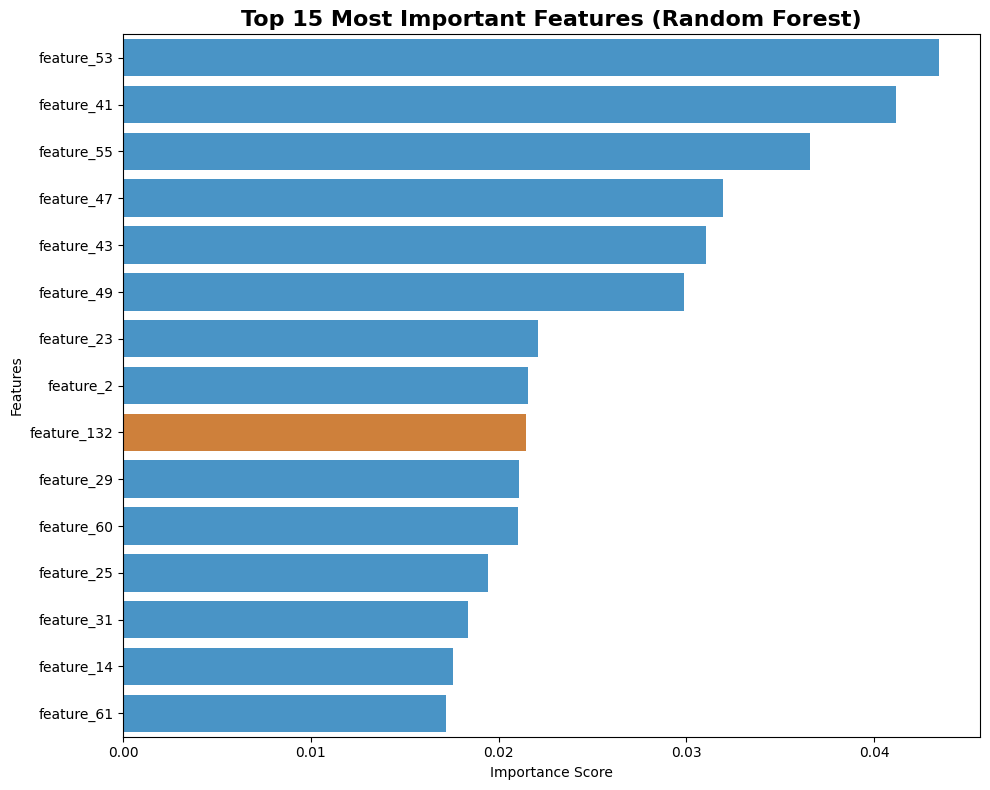

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_features_rf(model, x_train, top_n=15):
    # 1. Extract importances (NumPy array) and feature names
    importances = model.feature_importances_
    feature_names = x_train.columns

    # 2. Directly create the DataFrame (they are already perfectly aligned by index)
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # 3. Filter and Sort
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(top_n)

    # 4. Color mapping based on feature types
    colors = []
    for feat in importance_df['Feature']:
        if 'time_step' in feat:
             colors.append('#95a5a6')  # Gray for time steps
        else:
            try:
                # Assuming 'feature_1' format
                feat_num = int(feat.split('_')[1])
                colors.append('#3498db' if feat_num <= 93 else '#e67e22')
            except:
                colors.append('#3498db')

    # 5. Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette=colors)
    plt.title(f'Top {top_n} Most Important Features (Random Forest)', fontsize=16, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

# Run it
plot_top_features_rf(rf_all_model, x_all_train)

C:\Users\pansm\AppData\Local\Temp\ipykernel_18084\2341723667.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)


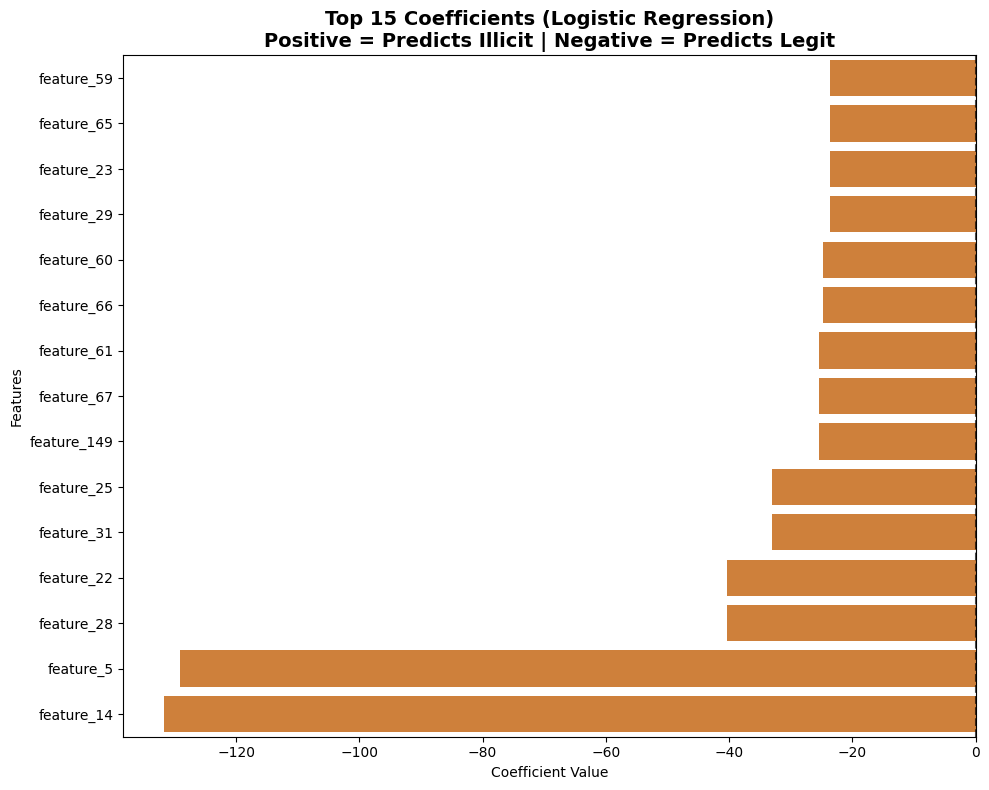

In [27]:
import numpy as np

def plot_top_features_lr(model, x_train, top_n=15):
    # 1. Extract coefficients for binary classification
    coefficients = model.coef_[0]
    feature_names = x_train.columns

    # 2. Create DataFrame with both raw values and absolute values for sorting
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Abs_Coefficient': np.abs(coefficients)
    })

    # 3. Sort by absolute impact and grab top N
    coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(top_n)

    # 4. Re-sort by actual coefficient value so the plot looks organized
    coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

    # 5. Color map: Blue for positive (Illicit risk), Orange for negative (Legit risk)
    colors = ['#3498db' if c > 0 else '#e67e22' for c in coef_df['Coefficient']]

    # 6. Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)

    # Add a vertical line at 0
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)

    plt.title(f'Top {top_n} Coefficients (Logistic Regression)\nPositive = Predicts Illicit | Negative = Predicts Legit',
              fontsize=14, fontweight='bold')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

# Run it (replace lr_model with your actual Logistic Regression model variable)
plot_top_features_lr(lr_all_model, x_all_train)

## Training on 'all' features with sliding window technique

Starting Multi-Model Rolling Window Simulation (Window Size: 12 steps)...
------------------------------------------------------------------------------------------
Simulating Step 35 | Train Steps: 23-32 | Val Steps: 33-34


C:\Users\pansm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Simulating Step 36 | Train Steps: 24-33 | Val Steps: 34-35


C:\Users\pansm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Simulating Step 37 | Train Steps: 25-34 | Val Steps: 35-36


...

Simulating Step 48 | Train Steps: 36-45 | Val Steps: 46-47


C:\Users\pansm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Simulating Step 49 | Train Steps: 37-46 | Val Steps: 47-48


C:\Users\pansm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


------------------------------------------------------------------------------------------
Simulation Complete.


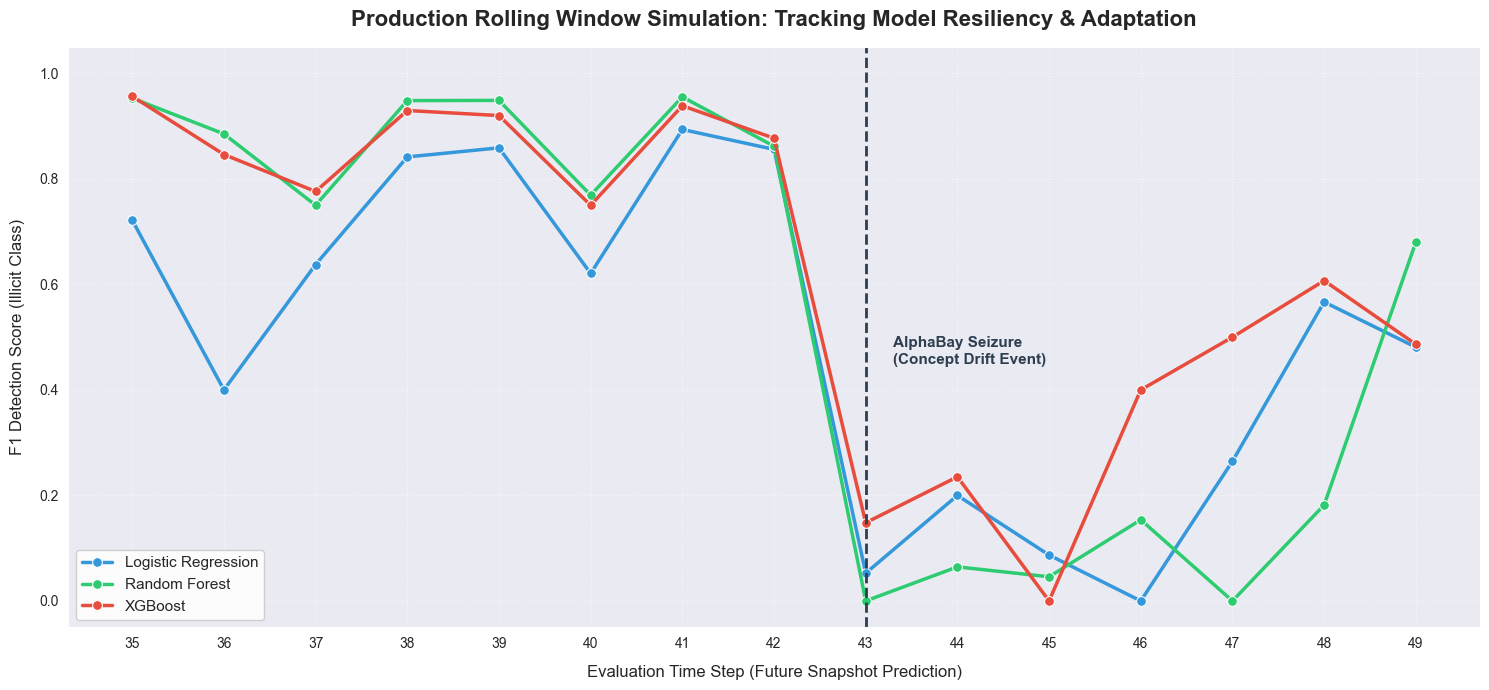

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

def run_multi_model_rolling_evaluation(splits, models_dict, window_size=10, val_size=2, start_test_step=35, max_step=49):
    """
    Executes a rolling window simulation across multiple models.
    For each target step, it splits historical data into a training window and a validation window,
    finds the best threshold per model on validation data, and evaluates on the target step.
    """
    # 1. Recombine features and targets seamlessly across all original splits
    # Extracting using the 'all' feature set to maintain network features
    x_tr, y_tr = extract_xy(splits.train, feature_set="all")
    x_va, y_va = extract_xy(splits.validation, feature_set="all")
    x_te, y_te = extract_xy(splits.test, feature_set="all")

    X_full = pd.concat([x_tr, x_va, x_te], axis=0).reset_index(drop=True)
    y_full = pd.concat([y_tr, y_va, y_te], axis=0).reset_index(drop=True)

    # Track performance metrics across time steps
    rolling_results = {model_name: [] for model_name in models_dict.keys()}
    evaluated_steps = []

    print(f"Starting Multi-Model Rolling Window Simulation (Window Size: {window_size} steps)...")
    print("-" * 90)

    for target_step in range(start_test_step, max_step + 1):
        # Determine specific window boundaries
        # Example: for target 35, window is 23-34. Train: 23-32, Val: 33-34
        window_start = target_step - window_size
        train_end = target_step - val_size - 1
        val_start = target_step - val_size
        val_end = target_step - 1

        # Build logical row masks
        train_mask = (X_full['time_step'] >= window_start) & (X_full['time_step'] <= train_end)
        val_mask = (X_full['time_step'] >= val_start) & (X_full['time_step'] <= val_end)
        test_mask = (X_full['time_step'] == target_step)

        # Ensure target test step contains data to evaluate
        if not test_mask.any() or y_full[test_mask].sum() == 0:
            continue

        evaluated_steps.append(target_step)

        # Isolate slices and drop metadata columns before fitting models
        X_train_w = X_full[train_mask].drop(columns=['time_step'])
        y_train_w = y_full[train_mask]

        X_val_w = X_full[val_mask].drop(columns=['time_step'])
        y_val_w = y_full[val_mask]

        X_test_w = X_full[test_mask].drop(columns=['time_step'])
        y_test_w = y_full[test_mask]

        print(f"Simulating Step {target_step:02d} | Train Steps: {window_start}-{train_end} | Val Steps: {val_start}-{val_end}")

        # Process each model architecture individually
        for model_name, model_init_func in models_dict.items():
            # Instantiate a fresh instance with your tuned parameters
            model = model_init_func()

            # Step-level feature standardization inside the loop boundaries
            # Crucial to prevent look-ahead scaling leakages
            if model_name == "Logistic Regression":
                # Logistic Regression needs scaled inputs to converge properly
                from sklearn.preprocessing import StandardScaler
                scaler_w = StandardScaler()
                X_train_processed = scaler_w.fit_transform(X_train_w)
                X_val_processed = scaler_w.transform(X_val_w)
                X_test_processed = scaler_w.transform(X_test_w)
            else:
                # Tree models handle unscaled structures perfectly
                X_train_processed = X_train_w
                X_val_processed = X_val_w
                X_test_processed = X_test_w

            # Train model on window subset
            model.fit(X_train_processed, y_train_w)

            # Use dynamic validation slice to find optimal F1 score threshold
            val_probs = model.predict_proba(X_processed_val := X_val_processed)[:, 1]
            best_threshold = 0.5
            best_val_f1 = -1

            # Quick threshold scan
            for th in np.linspace(0.1, 0.9, 17):
                v_f1 = f1_score(y_val_w, (val_probs >= th).astype(int), pos_label=1, zero_division=0)
                if v_f1 > best_val_f1:
                    best_val_f1 = v_f1
                    best_threshold = th

            # Predict the future target step using the optimized threshold
            test_probs = model.predict_proba(X_test_processed)[:, 1]
            test_preds = (test_probs >= best_threshold).astype(int)

            # Calculate final test metric for the Illicit Class
            step_f1 = f1_score(y_test_w, test_preds, pos_label=1, zero_division=0)
            rolling_results[model_name].append(step_f1)

    print("-" * 90)
    print("Simulation Complete.")
    return evaluated_steps, rolling_results

# Define your models using your exact configurations from your optimization steps
configured_models = {
    "Logistic Regression": lambda: build_logistic_regression(
        solver='lbfgs', penalty='l2', C=9642.769, class_weight=None, max_iter=1500
    ),
    "Random Forest": lambda: build_random_forest(
        n_estimators=500, max_depth=None, min_samples_split=20, min_samples_leaf=11,
        max_features='log2', class_weight='balanced_subsample'
    ),
    "XGBoost": lambda: build_xgboost(
        learning_rate=0.13619, n_estimators=300, max_depth=7, min_child_weight=2,
        gamma=1.6113, subsample=0.5656, colsample_bytree=0.5760,
        reg_alpha=9.76e-06, reg_lambda=1.21e-06, scale_pos_weight=scale_pos_weight
    )
}

# Run the system across an optimized 10-step lookback window
steps, metrics_series = run_multi_model_rolling_evaluation(
    splits=splits,
    models_dict=configured_models,
    window_size=12,  # Total lookback horizon
    val_size=2       # Moving validation buffer to optimize detection thresholds
)

# 2. Visualize Recovery Timelines
plt.figure(figsize=(15, 7))
palette = {"Logistic Regression": "#3498db", "Random Forest": "#2ecc71", "XGBoost": "#e74c3c"}

for model_name, score_list in metrics_series.items():
    sns.lineplot(
        x=steps, y=score_list, marker='o', label=model_name,
        color=palette[model_name], linewidth=2.5, markersize=7
    )

# Visualizing the Black Swan structural anomaly
plt.axvline(x=43, color='#2c3e50', linestyle='--', linewidth=2)
plt.text(43.3, 0.45, 'AlphaBay Seizure\n(Concept Drift Event)', color='#2c3e50', weight='bold', fontsize=11)

plt.title('Production Rolling Window Simulation: Tracking Model Resiliency & Adaptation', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Evaluation Time Step (Future Snapshot Prediction)', fontsize=12, labelpad=10)
plt.ylabel('F1 Detection Score (Illicit Class)', fontsize=12, labelpad=10)
plt.xticks(steps)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()